### Fetching Data

In [1]:
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

In [2]:
y['Diagnosis'].value_counts()

Diagnosis
B    357
M    212
Name: count, dtype: int64

In [3]:
X_train.to_parquet('data/train/features.parquet', index=False)
y_train.to_parquet('data/train/targets.parquet', index=False)

X_test.to_parquet('data/test/features.parquet', index=False)
y_test.to_parquet('data/test/targets.parquet', index=False)

### Train the VAE

In [4]:
import pandas as pd
import numpy as np
import torch

In [5]:
from datasets import WDBCDataModule
from models import VAE
from l_modules import VAEModule
from generate import generate_synthetic_data

In [6]:
import lightning as l

model = VAE(input_dim=31, latent_dim=16)
data_module = WDBCDataModule(mode='train', batch_size=32)
trainer = l.Trainer(
    max_epochs=500,
    accelerator='auto',
    log_every_n_steps=1,
)

vae_module = VAEModule(model)
trainer.fit(vae_module, data_module)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ VAE  │  101 K │ train │     0 │
└───┴───────┴──────┴────────┴───────┴───────┘

Trainable params: 101 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 101 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 18                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/toga/miniconda3/envs/ds/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/toga/miniconda3/envs/ds/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


`Trainer.fit` stopped: `max_epochs=500` reached.


We can now plot the loss history, with their components to see how well the model converged

Text(0.5, 1.0, 'Loss History')

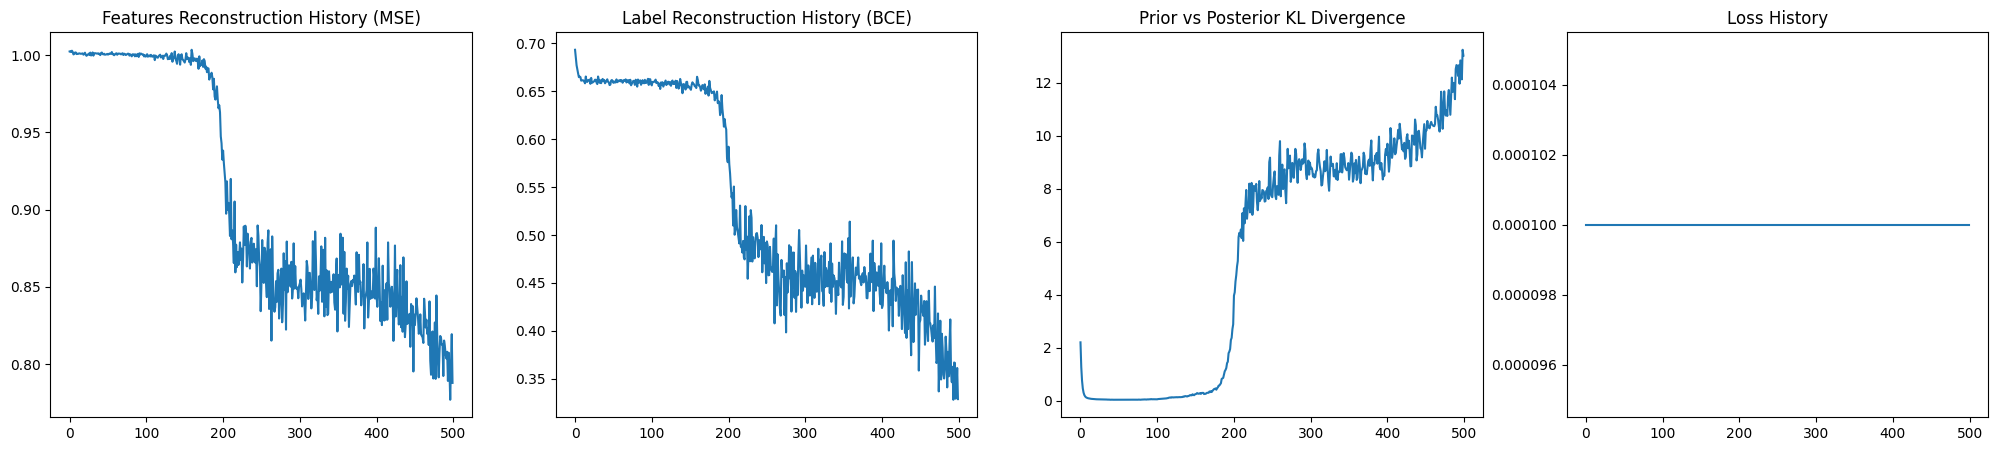

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 4, figsize=(25, 5))
ax[0].plot(vae_module.reconstruction_feats_history_epoch)
ax[1].plot(vae_module.reconstruction_labels_epoch)
ax[2].plot(vae_module.kl_div_loss_history_epoch)
ax[3].plot(vae_module.lr_history)

ax[0].set_title('Features Reconstruction History (MSE)')
ax[1].set_title('Label Reconstruction History (BCE)')
ax[2].set_title('Prior vs Posterior KL Divergence')
ax[3].set_title('Loss History')

A helpful heuristic for seeing how well the model generates data is by doing a direct UMAP projection of our test data against our synthetically generated data and see how well they overlap:

/Users/toga/miniconda3/envs/ds/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


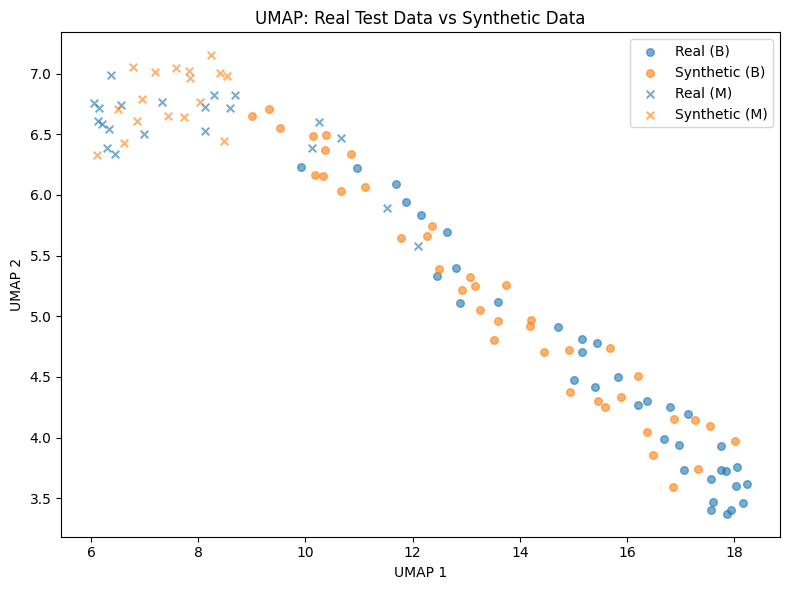

In [ ]:
import umap
import matplotlib.pyplot as plt

X_test_raw = pd.read_parquet('data/test/features.parquet')
y_test_raw = pd.read_parquet('data/test/targets.parquet').squeeze()
y_test_binary = pd.get_dummies(y_test_raw, drop_first=True).values.ravel()

synthetic_df = generate_synthetic_data(model, data_module, num_samples=len(X_test_raw))
X_synth = synthetic_df[data_module.feature_columns].values
y_synth = synthetic_df[data_module.target_column].values

X_combined = np.vstack([X_test_raw.values, X_synth])

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(X_combined)

emb_real = embedding[:len(X_test_raw)]
emb_synth = embedding[len(X_test_raw):]

fig, ax = plt.subplots(figsize=(8, 6))

for diag, marker in [(0, 'o'), (1, 'x')]:
    mask_real = y_test_binary == diag
    ax.scatter(emb_real[mask_real, 0], emb_real[mask_real, 1],
               marker=marker, alpha=0.6, s=30, c='tab:blue',
               label=f'Real ({"M" if diag else "B"})')

    mask_synth = y_synth == diag
    ax.scatter(emb_synth[mask_synth, 0], emb_synth[mask_synth, 1],
               marker=marker, alpha=0.6, s=30, c='tab:orange',
               label=f'Synthetic ({"M" if diag else "B"})')

ax.set_title('UMAP: Real Test Data vs Synthetic Data')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend()
plt.tight_layout()
plt.show()